In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

logs_df = pd.read_csv('saudi_website_visitors_data.csv')

print(logs_df.head())

                                user_id  is_registered  \
0  91adc685-d95d-48ec-a4d0-8947353510d8           True   
1  8586acca-d0d9-47c3-81b5-99d2372a5489          False   
2  74c66aee-b565-4e79-a78d-d0fa7f3d77de           True   
3  52f3a68e-967d-49ea-b107-3db2a78a6186           True   
4  d356b7f7-5f6e-4e0a-b3bd-9500905930fa           True   

               visit_datetime                            session_id  \
0  2025-06-23 22:49:05.731962  ded5cac7-d160-4a43-b21b-4f4927f56800   
1  2025-06-28 09:23:50.498516  e7c070da-24e0-44e5-a4b4-9226a244a1ba   
2  2025-06-20 18:05:42.252888  8edddc95-17c6-4394-a302-ec6b4c5e7580   
3  2025-06-30 04:02:32.799995  a881f33f-ad3a-45a8-9c26-6846141f45b5   
4  2025-06-24 09:31:14.554307  5c7dd83e-f10d-4f47-a2a2-0758fdfc4a47   

  device_type browser  referrer  page_views  session_duration_sec  \
0     Desktop  Safari  Snapchat          10                   493   
1      Tablet  Chrome  Snapchat          10                   105   
2      Tablet    

In [2]:
print(logs_df.columns.tolist())

['user_id', 'is_registered', 'visit_datetime', 'session_id', 'device_type', 'browser', 'referrer', 'page_views', 'session_duration_sec', 'country', 'city', 'signup_date', 'user_type', 'conversion', 'pages_visited', 'utm_source']


In [3]:
print(logs_df.shape)

(1500, 16)


In [4]:
logs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               1500 non-null   str  
 1   is_registered         1500 non-null   bool 
 2   visit_datetime        1500 non-null   str  
 3   session_id            1500 non-null   str  
 4   device_type           1500 non-null   str  
 5   browser               1500 non-null   str  
 6   referrer              1500 non-null   str  
 7   page_views            1500 non-null   int64
 8   session_duration_sec  1500 non-null   int64
 9   country               1500 non-null   str  
 10  city                  1500 non-null   str  
 11  signup_date           757 non-null    str  
 12  user_type             1500 non-null   str  
 13  conversion            1500 non-null   bool 
 14  pages_visited         1500 non-null   str  
 15  utm_source            1136 non-null   str  
dtypes: bool(2), int64

In [5]:
print(logs_df.isnull().sum())

user_id                   0
is_registered             0
visit_datetime            0
session_id                0
device_type               0
browser                   0
referrer                  0
page_views                0
session_duration_sec      0
country                   0
city                      0
signup_date             743
user_type                 0
conversion                0
pages_visited             0
utm_source              364
dtype: int64


In [6]:
logs_df.describe()

,page_views,session_duration_sec
count,1500.000000,1500.000000
mean,5.512667,617.706000
std,2.840755,333.896823
min,1.000000,31.000000
25%,3.000000,327.000000
50%,6.000000,606.500000
75%,8.000000,901.000000
max,10.000000,1200.000000


In [7]:
print("Duplicate rows:", logs_df.duplicated().sum())

print("Negative page views:",
      (logs_df['page_views'] < 0).sum())

print("Negative session durations:",
      (logs_df['session_duration_sec'] < 0).sum())

print("Sessions:", logs_df['session_id'].nunique())

print("Devices:")
print(logs_df['device_type'].value_counts())

Duplicate rows: 0
Negative page views: 0
Negative session durations: 0
Sessions: 1500
Devices:
device_type
Tablet     521
Desktop    494
Mobile     485
Name: count, dtype: int64


fix time and date

In [8]:
logs_df['visit_datetime'] = pd.to_datetime(
    logs_df['visit_datetime'],
    errors='coerce'
)

In [9]:
print(
    "Invalid dates:",
    logs_df['visit_datetime'].isna().sum()
)

Invalid dates: 0


Create session

In [10]:
logs_df.groupby('session_id')['page_views'].apply(
    lambda x: x == 1
).mean()

np.float64(0.09666666666666666)

In [11]:
session_summary = (
    logs_df.groupby('session_id')
    .agg(
        page_views=('page_views', 'sum'),
        session_duration=('session_duration_sec', 'first'),
        device_type=('device_type', 'first')
    )
    .reset_index()
)

session_summary.head()

,session_id,page_views,session_duration,device_type
0,007a0e2f-eb44-4a8f-a7d8-95b1e126b3bc,4,804,Desktop
1,00c90371-c893-4589-8b98-5ee29234cc66,5,713,Desktop
2,01135532-69ca-4c1a-869b-88dd86107528,7,621,Desktop
3,0126870e-2e33-4bc6-ac68-00744305f442,1,606,Mobile
4,01377d20-d5dd-4836-83df-9fe42257b689,3,344,Tablet


Correct the bounce rate

In [12]:
session_summary['is_bounce'] = (
    session_summary['page_views'] == 1
)

In [13]:
bounce_rate = (
    session_summary['is_bounce'].mean() * 100
)

print(f"Bounce Rate: {bounce_rate:.2f}%")

Bounce Rate: 9.67%


Calculate pages per session

In [14]:
pages_per_session = session_summary['page_views'].mean()

print(
    f"Average Pages per Session: "
    f"{pages_per_session:.2f}"
)

Average Pages per Session: 5.51


In [15]:
valid_durations = session_summary[
    session_summary['session_duration'] >= 0
]

avg_session_time = (
    valid_durations['session_duration'].mean()
)

print(
    f"Average Session Time: "
    f"{avg_session_time:.2f} seconds"
)

Average Session Time: 617.71 seconds


In [16]:
avg_session_minutes = avg_session_time / 60

print(
    f"Average Session Time: "
    f"{avg_session_minutes:.2f} minutes"
)

Average Session Time: 10.30 minutes


Device-level engagement

In [20]:
device_metrics = (
    session_summary
    .groupby('device_type')
    .agg(
        sessions=('session_id', 'nunique'),
        avg_session_time=('session_duration', 'mean'),
        avg_pages_per_session=('page_views', 'mean'),
        bounce_rate=('is_bounce', 'mean')
    )
    .reset_index()
)




In [21]:
device_metrics['bounce_rate'] *= 100

In [22]:
device_metrics

,device_type,sessions,avg_session_time,avg_pages_per_session,bounce_rate
0,Desktop,494,619.404858,5.406883,10.121457
1,Mobile,485,604.358763,5.672165,8.453608
2,Tablet,521,628.520154,5.464491,10.364683


Vizzzz

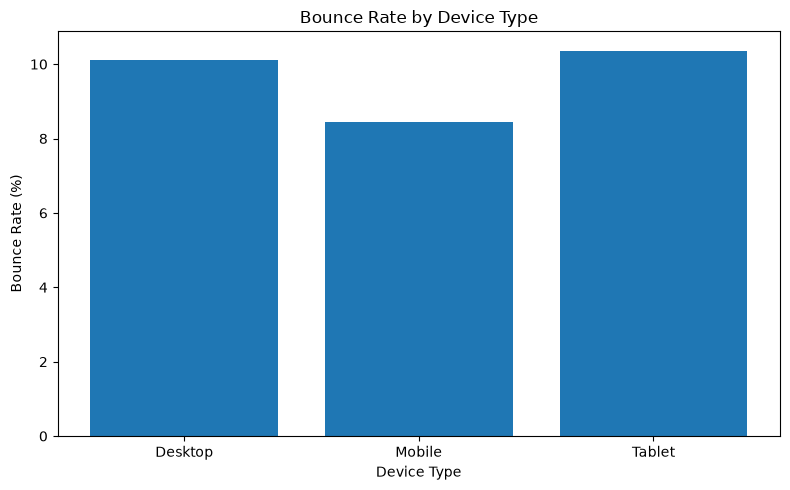

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    device_metrics['device_type'],
    device_metrics['bounce_rate']
)

plt.title('Bounce Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Bounce Rate (%)')

plt.tight_layout()
plt.show()

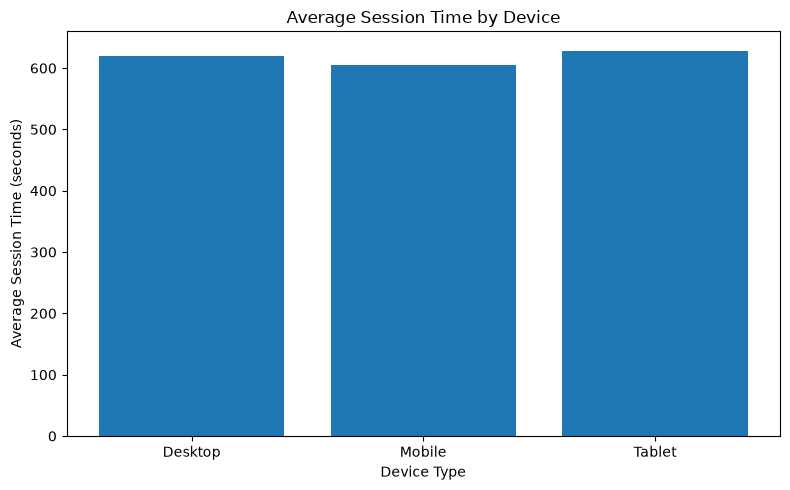

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    device_metrics['device_type'],
    device_metrics['avg_session_time']
)

plt.title('Average Session Time by Device')
plt.xlabel('Device Type')
plt.ylabel('Average Session Time (seconds)')

plt.tight_layout()
plt.show()

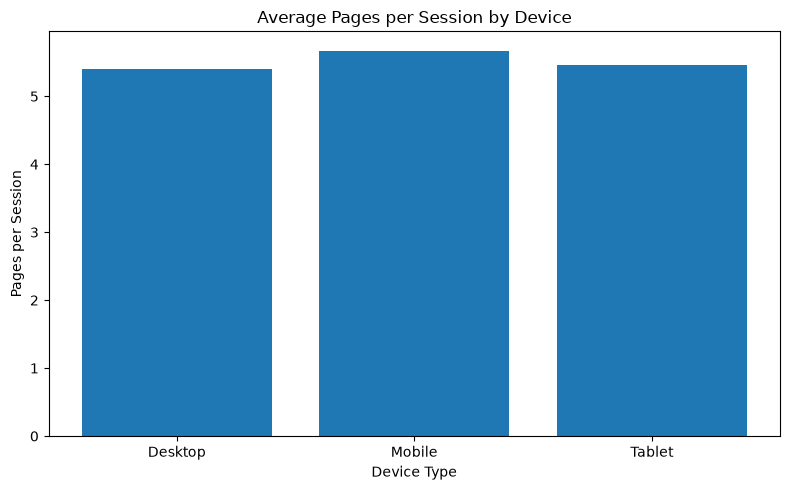

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    device_metrics['device_type'],
    device_metrics['avg_pages_per_session']
)

plt.title('Average Pages per Session by Device')
plt.xlabel('Device Type')
plt.ylabel('Pages per Session')

plt.tight_layout()
plt.show()

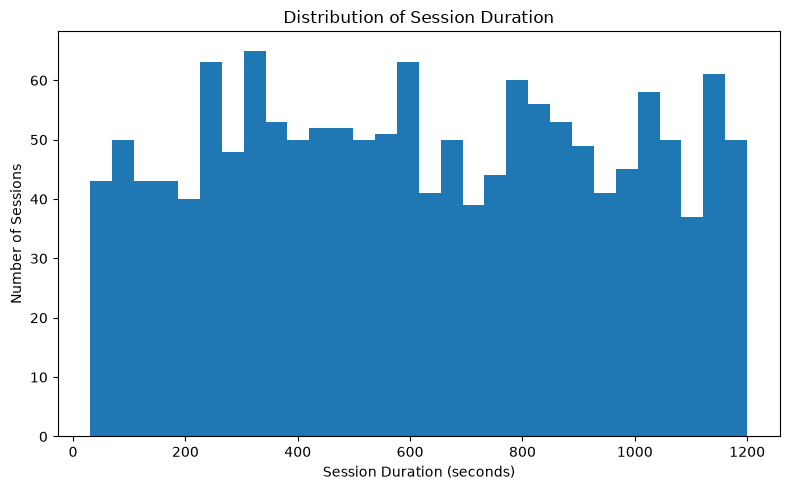

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    session_summary['session_duration'],
    bins=30
)

plt.title('Distribution of Session Duration')
plt.xlabel('Session Duration (seconds)')
plt.ylabel('Number of Sessions')

plt.tight_layout()
plt.show()

In [27]:
logs_df.shape
logs_df.columns.tolist()
logs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               1500 non-null   str           
 1   is_registered         1500 non-null   bool          
 2   visit_datetime        1500 non-null   datetime64[us]
 3   session_id            1500 non-null   str           
 4   device_type           1500 non-null   str           
 5   browser               1500 non-null   str           
 6   referrer              1500 non-null   str           
 7   page_views            1500 non-null   int64         
 8   session_duration_sec  1500 non-null   int64         
 9   country               1500 non-null   str           
 10  city                  1500 non-null   str           
 11  signup_date           757 non-null    str           
 12  user_type             1500 non-null   str           
 13  conversion            1500 no

In [28]:
print("Dataset shape:", logs_df.shape)

print("\nDuplicate rows:")
print(logs_df.duplicated().sum())

print("\nMissing values:")
print(logs_df.isnull().sum())

print("\nNegative page views:")
print((logs_df['page_views'] < 0).sum())

print("\nNegative session durations:")
print((logs_df['session_duration_sec'] < 0).sum())

print("\nUnique sessions:")
print(logs_df['session_id'].nunique())

print("\nDevice types:")
print(logs_df['device_type'].value_counts())

Dataset shape: (1500, 16)

Duplicate rows:
0

Missing values:
user_id                   0
is_registered             0
visit_datetime            0
session_id                0
device_type               0
browser                   0
referrer                  0
page_views                0
session_duration_sec      0
country                   0
city                      0
signup_date             743
user_type                 0
conversion                0
pages_visited             0
utm_source              364
dtype: int64

Negative page views:
0

Negative session durations:
0

Unique sessions:
1500

Device types:
device_type
Tablet     521
Desktop    494
Mobile     485
Name: count, dtype: int64


In [29]:
logs_df[
    ['page_views', 'session_duration_sec']
].describe()

,page_views,session_duration_sec
count,1500.000000,1500.000000
mean,5.512667,617.706000
std,2.840755,333.896823
min,1.000000,31.000000
25%,3.000000,327.000000
50%,6.000000,606.500000
75%,8.000000,901.000000
max,10.000000,1200.000000


In [30]:
logs_df[
    ['page_views', 'session_duration_sec']
].describe()

,page_views,session_duration_sec
count,1500.000000,1500.000000
mean,5.512667,617.706000
std,2.840755,333.896823
min,1.000000,31.000000
25%,3.000000,327.000000
50%,6.000000,606.500000
75%,8.000000,901.000000
max,10.000000,1200.000000


In [31]:
print("Maximum page views:",
      logs_df['page_views'].max())

print("Maximum session duration:",
      logs_df['session_duration_sec'].max(),
      "seconds")

Maximum page views: 10
Maximum session duration: 1200 seconds


Create session-level data

In [32]:
session_counts = logs_df['session_id'].value_counts()

print(session_counts.describe())


count    1500.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64


In [33]:
print("Number of unique sessions:",
      logs_df['session_id'].nunique())

print("Number of records:",
      len(logs_df))

Number of unique sessions: 1500
Number of records: 1500


In [34]:
print(
    "Sessions with multiple records:",
    (session_counts > 1).sum()
)

Sessions with multiple records: 0


In [35]:
bounce_rate = (
    logs_df['page_views'].eq(1).mean() * 100
)

print(f"Bounce Rate: {bounce_rate:.2f}%")

Bounce Rate: 9.67%


In [36]:
assert 0 <= bounce_rate <= 100

print("Bounce rate validation passed.")

Bounce rate validation passed.


In [37]:
avg_session_time = logs_df[
    'session_duration_sec'
].mean()

print(
    f"Average Session Time: "
    f"{avg_session_time:.2f} seconds"
)

Average Session Time: 617.71 seconds


In [38]:
print("Bounce Rate:", bounce_rate)
print("Average Session Time:", avg_session_time)
print("Pages per Session:", pages_per_session)

device_metrics

Bounce Rate: 9.666666666666666
Average Session Time: 617.706
Pages per Session: 5.512666666666667


,device_type,sessions,avg_session_time,avg_pages_per_session,bounce_rate
0,Desktop,494,619.404858,5.406883,10.121457
1,Mobile,485,604.358763,5.672165,8.453608
2,Tablet,521,628.520154,5.464491,10.364683


9.67% bounce rate: About 1 in 10 sessions involved only one page view.

617.71 seconds average session time: Users spend approximately 10.3 minutes per session.

5.51 pages per session: Users view about 5–6 pages per session, suggesting relatively strong engagement.

Tablet

Has the highest average session time: 628.52 seconds.

Has the highest bounce rate: 10.36%.

This means tablet users spend the longest time on the website, but are also slightly more likely to leave after viewing one page.

Final

In [39]:
def analyze_user_engagement(logs_df):

    # Make a copy to avoid modifying the original dataframe
    data = logs_df.copy()

    # Validate required columns
    required_columns = [
        'session_id',
        'page_views',
        'session_duration_sec',
        'device_type'
    ]

    missing_columns = [
        col for col in required_columns
        if col not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    # Validate page views
    if (data['page_views'] < 0).any():
        raise ValueError(
            "Page views cannot be negative."
        )

    # Validate session duration
    if (data['session_duration_sec'] < 0).any():
        raise ValueError(
            "Session duration cannot be negative."
        )

    # Overall metrics
    bounce_rate = (
        data['page_views'].eq(1).mean() * 100
    )

    avg_session_time = (
        data['session_duration_sec'].mean()
    )

    pages_per_session = (
        data['page_views'].mean()
    )

    metrics = {
        'bounce_rate': bounce_rate,
        'avg_session_time_sec': avg_session_time,
        'pages_per_session': pages_per_session,
        'total_sessions': data['session_id'].nunique()
    }

    # Device-level metrics
    device_metrics = (
        data.groupby('device_type')
        .agg(
            sessions=('session_id', 'nunique'),
            avg_session_time=(
                'session_duration_sec', 'mean'
            ),
            avg_pages_per_session=(
                'page_views', 'mean'
            )
        )
        .reset_index()
    )

    # Bounce rate by device
    device_bounce = (
        data.groupby('device_type')['page_views']
        .apply(
            lambda x: x.eq(1).mean() * 100
        )
        .reset_index(name='bounce_rate')
    )

    device_metrics = device_metrics.merge(
        device_bounce,
        on='device_type'
    )

    return metrics, device_metrics

test

In [40]:
metrics, device_metrics = analyze_user_engagement(logs_df)

print(metrics)

device_metrics

{'bounce_rate': np.float64(9.666666666666666), 'avg_session_time_sec': np.float64(617.706), 'pages_per_session': np.float64(5.512666666666667), 'total_sessions': 1500}


,device_type,sessions,avg_session_time,avg_pages_per_session,bounce_rate
0,Desktop,494,619.404858,5.406883,10.121457
1,Mobile,485,604.358763,5.672165,8.453608
2,Tablet,521,628.520154,5.464491,10.364683


1. How did different prompts approach error identification?

The initial prompt focused mainly on the obvious symptoms: bounce rates above 100% and negative session times. More refined prompts examined the underlying calculation logic. They identified that the original bounce-rate calculation produced Boolean values incorrectly, that counting rows was not necessarily the same as counting unique sessions, and that session duration needed to be validated rather than blindly summed.

2. What validation methods were suggested?

The refined solution included:

Checking for missing values.
Checking for duplicate records.
Checking for negative page views.
Checking for negative session durations.
Checking that the bounce rate is between 0% and 100%.
Checking that required columns exist.
Counting unique sessions using nunique().
Validating and converting date/time fields.

3. How was time handling improved?

The refined solution uses the dataset's actual session_duration_sec field and validates that durations are non-negative. The duration is then reported both in seconds and minutes, making the metric easier to interpret.